<a href="https://colab.research.google.com/github/abdoulkaderblagna908-oss/Projet-Probabilit-s-Statistiques-Groupe-BBC/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projet: <u>Analyse statistique et modélisation probabiliste de la fraude dans les assurances automobiles</u>

In [15]:
# importation de bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# chargement des données
url = "https://raw.githubusercontent.com/abdoulkaderblagna908-oss/Projet-Probabilit-s-Statistiques-Groupe-BBC/main/data/data_from_carclaims.csv"
df = pd.read_csv(url)

In [17]:
df.head()

,FraudFound,AccidentArea,Age,VehiclePrice,PastNumberOfClaims,Fault
0,No,Urban,21,"more than 69,000",none,Policy Holder
1,No,Urban,34,"more than 69,000",none,Policy Holder
2,No,Urban,47,"more than 69,000",1,Policy Holder
3,No,Rural,65,"20,000 to 29,000",1,Third Party
4,No,Urban,27,"more than 69,000",none,Third Party


In [18]:
df.drop(columns="AccidentArea", inplace=True)
df.drop(columns="Age", inplace=True)

In [19]:
df.head()

,FraudFound,VehiclePrice,PastNumberOfClaims,Fault
0,No,"more than 69,000",none,Policy Holder
1,No,"more than 69,000",none,Policy Holder
2,No,"more than 69,000",1,Policy Holder
3,No,"20,000 to 29,000",1,Third Party
4,No,"more than 69,000",none,Third Party


In [20]:
df['PastNumberOfClaims'].value_counts()

,count
PastNumberOfClaims,
2 to 4,5485
none,4352
1,3573
more than 4,2010


## Analyse descriptive

On fera les analyses pour chaque variable

In [21]:
columns = df.columns

<u>Variable 1</u>: FraudFound



In [22]:
var1 = df[columns[0]]

In [23]:
data = {
            'Loi de probabilité': 'Bernouilli (p = 6%)',
            'Moyenne': 0.06,
            'Ecart-type': 0.237,
            'Nombre de cas de fraude': 923,
            'Nombre de cas sans fraude': 14497
        }
for i in data:
    print(f"{i :.<50} {data[i]}")

Loi de probabilité................................ Bernouilli (p = 6%)
Moyenne........................................... 0.06
Ecart-type........................................ 0.237
Nombre de cas de fraude........................... 923
Nombre de cas sans fraude......................... 14497


In [24]:
var1.value_counts()

,count
FraudFound,
No,14497
Yes,923


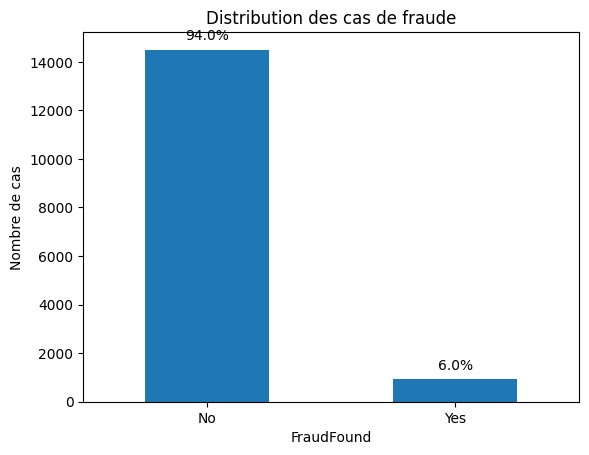

In [25]:
counts = var1.value_counts()
percentages = counts / len(var1) * 100

fig, ax = plt.subplots()
counts.plot(kind="bar", ax=ax)

for i, p in enumerate(ax.patches):
    ax.annotate(f'{percentages.iloc[i]:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

plt.title("Distribution des cas de fraude")
plt.ylabel("Nombre de cas")
plt.xlabel("FraudFound")
plt.xticks(rotation=0)
plt.savefig("FraudFound.png")
plt.show()

La probilité de fraude  
$\mathbb{P}(fraude) = \frac{\text{nombre_cas_de_fraude}}{\text{nombre_total_de_cas}}$

In [26]:
P_fraude = var1.value_counts()[1] / len(var1)


/tmp/ipykernel_2380/1280000243.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  P_fraude = var1.value_counts()[1] / len(var1)


In [27]:
print("P_fraude =", "% .2f" % (P_fraude*100), "%")

P_fraude =  5.99 %


Loi de probabilité: La variable caractésisant les cas de fraude chez les assurés suit une **loi de Bernouilli** de paramètre $p \simeq 6 \% $.  
Expérance mathématique: $\mathbb{E}(\text{FraudFound}) = p = 0.06$  
Variance: $\mathbb{V}(\text{FraudFound}) = p(1-p) = 0.056$  
Ecart-type: $\mathbb{\sigma}(\text{FraudFound}) = \sqrt{\mathbb{V}(\text{FraudFound})} = 0.237$

Il covient d'encoder la variable FraudFound selon:
$\begin{cases} Yes = 1 \\ No = 0 \end{cases}$

In [28]:
# Encodage
df1 = df.copy()
df1[columns[0]] = df[columns[0]].apply(lambda x: 1 if x == "Yes" else 0)

<u>Interprétation:</u> La moyenne de la variable est 0.06; ce qui est proche de 0. Donc, la plupart des assurés ne fraudent pas.

In [29]:
P_fraude*(1-P_fraude)

np.float64(0.05627442841257585)

In [30]:
np.sqrt(P_fraude*(1-P_fraude))

np.float64(0.2372223185380664)

In [31]:
def normal(var, x):
  mean = np.mean(var)
  std = np.std(var)
  return (1/(std * np.sqrt(2 * np.pi))) * np.exp( - (x - mean)**2 / (2 * std**2))

<u>Variable 4: VehiclePrice</u>  


In [32]:
var4 = df1[columns[1]]

<u>Encodage de la variable VehiclePrice</u>

In [33]:
def encoder(var):
  intervals = var.unique()
  code = {}
  for interval in intervals:
    if 'to' in interval:
      a, b = [int(x.replace(',', '')) for x in interval.split(' to ')]
      code[interval] = (a + b)/2

    elif "less" in interval:
      a = interval.split()[-1].replace(",", "")
      a = int(a)
      code[interval] = a/2
    elif "none" in interval:
      code[interval] = 0
    elif interval == "1":
      code[interval] = 1
    else:
      b = interval.split()[-1].replace(",", "")
      b = int(b)
      code[interval] = (b + 10000)//2
  return var.apply(lambda x: code[x])

In [34]:
var4 = encoder(var4)

In [35]:
df1[columns[1]] = var4

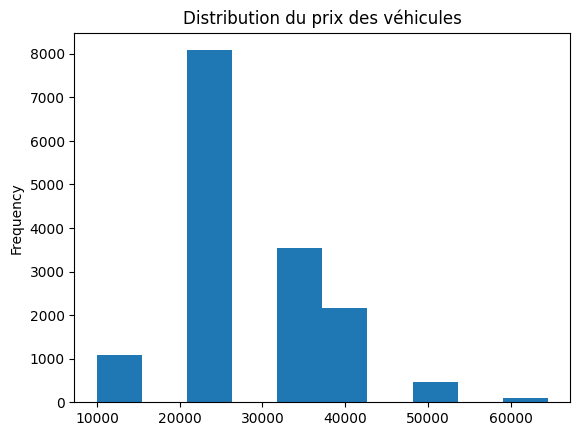

In [36]:
plt.title("Distribution du prix des véhicules")
var4.plot.hist()
plt.savefig("VehiclePrice_hist.png")
plt.show()

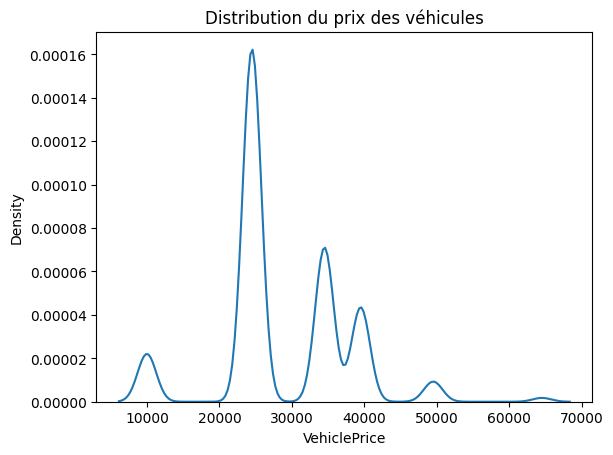

In [37]:
plt.title("Distribution du prix des véhicules")
sns.kdeplot(var4)
plt.savefig("VehiclePrice_kdeplot.png")
plt.show()

In [38]:
var4.describe()

,VehiclePrice
count,15420.000000
mean,28838.715953
std,8850.114536
min,10000.000000
25%,24500.000000
50%,24500.000000
75%,34500.000000
max,64500.000000


In [39]:
var4.skew()

np.float64(0.307623415039769)

La distribution empirique du prix des véhicules est multimodale (présence de plusieurs pics).
Elle ne peut donc pas être modélisée par une seule loi classique (normale ou log-normale).
Nous modélisons alors cette variable par un modèle de mélange de distributions normales correspondant aux différentes catégories de véhicules.  
$\text{VehiclePrice} = X_1 + X_2 + X_3 + X_4 + X_5$ où:  
$X_i \sim \text{LoiNormale}(\mu_i, \sigma_i^2)$

In [40]:
var5 = df1[columns[2]]

In [41]:
var5.value_counts()

,count
PastNumberOfClaims,
2 to 4,5485
none,4352
1,3573
more than 4,2010


In [42]:
#Encodage
def encoder2(var):
  intervals = var.unique()
  code = {}
  for interval in intervals:
    if 'to' in interval:
      a, b = [int(x.replace(',', '')) for x in interval.split(' to ')]
      code[interval] = (a + b)//2

    elif "less" in interval:
      a = interval.split()[-1].replace(",", "")
      a = int(a)
      code[interval] = a/2
    elif "none" in interval:
      code[interval] = 0
    elif interval == "1":
      code[interval] = 1
    else:
      code[interval] = 5
  return var.apply(lambda x: code[x])

In [43]:
var5 = encoder2(var5)

In [44]:
df1[columns[2]] = var5

In [68]:
var5.describe()

,PastNumberOfClaims
count,15420.000000
mean,1.950584
std,1.699188
min,0.000000
25%,0.000000
50%,1.000000
75%,3.000000
max,5.000000


In [45]:
var5.value_counts()

,count
PastNumberOfClaims,
3,5485
0,4352
1,3573
5,2010


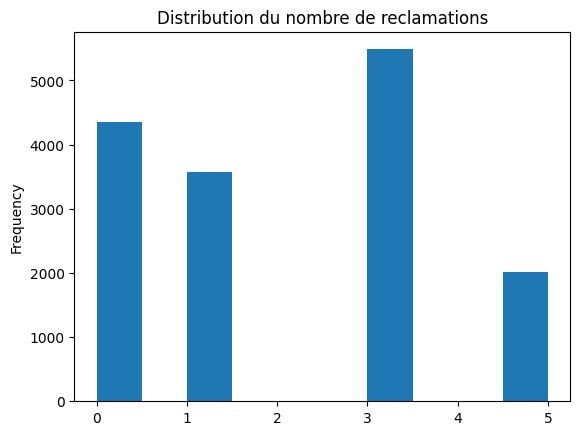

In [64]:
plt.title("Distribution du nombre de reclamations")

var5.plot.hist()
plt.savefig("PastNumberOfClaims_hist.png")
plt.show()

<u>Variable 4</u>:

In [47]:
var6 = df1[columns[3]]

In [67]:
var6.value_counts()

,count
Fault,
0,11230
1,4190


In [48]:
var6.value_counts(normalize=True)

,proportion
Fault,
Policy Holder,0.728275
Third Party,0.271725


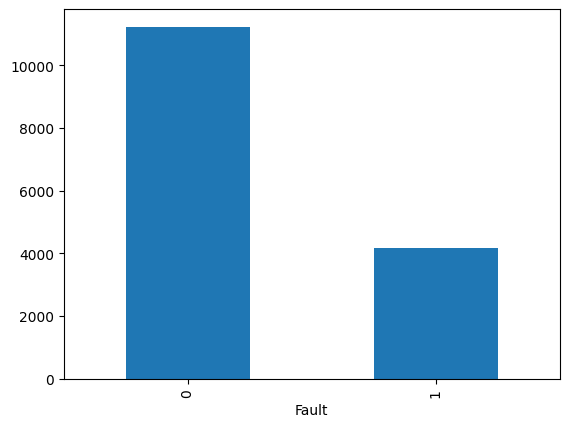

In [65]:

var6.value_counts().plot(kind="bar")
plt.savefig("Fault_hist.png")
plt.show()

<u>Loi de probabilité pour la variable 'Fault'</u>

La variable `Fault` est une variable catégorielle qui prend deux valeurs : 'Policy Holder' et 'Third Party'. Elle peut être modélisée par une **loi de Bernoulli**.

Nous avons les proportions suivantes :
*   $\mathbb{P}(\text{Fault} = \text{Policy Holder}) \approx 0.728$
*   $\mathbb{P}(\text{Fault} = \text{Third Party}) \approx 0.272$

Si l'on considère l'événement "Third Party" comme un succès (par exemple, codé 1), alors `Fault` suit une loi de Bernoulli de paramètre $p = 0.272$.

*   Espérance : $\mathbb{E}(\text{Fault}) = p = 0.272$
*   Variance : $\mathbb{V}(\text{Fault}) = p(1-p) = 0.272 \times (1 - 0.272) \approx 0.198$

In [66]:
np.sqrt(0.272*(1-0.272))

np.float64(0.44498988752554813)

<u>Interprétation</u>: La probabilité que l'assuré ne soit pas coupable de l'accident est de 27.2 %.

In [50]:
#Encodage
var6 = var6.apply(lambda x: 1 if x == "Third Party" else 0)

In [51]:
df1[columns[3]] = pd.DataFrame(var6)

In [52]:
url = "https://raw.githubusercontent.com/abdoulkaderblagna908-oss/Projet-Probabilit-s-Statistiques-Groupe-BBC/main/data/carclaims.csv"
data = pd.read_csv(url)

In [53]:
data.columns

Index(['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea',
       'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex',
       'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory',
       'VehiclePrice', 'PolicyNumber', 'RepNumber', 'Deductible',
       'DriverRating', 'Days:Policy-Accident', 'Days:Policy-Claim',
       'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder',
       'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange-Claim', 'NumberOfCars', 'Year',
       'BasePolicy', 'FraudFound'],
      dtype='object')

In [54]:
df1.head()

,FraudFound,VehiclePrice,PastNumberOfClaims,Fault
0,0,39500.0,0,0
1,0,39500.0,0,0
2,0,39500.0,1,0
3,0,24500.0,1,1
4,0,39500.0,0,1


## Analyse des variables influençant la fraude

Analyse de corrélations Corrélations





In [55]:
df1.corr()["FraudFound"]

,FraudFound
FraudFound,1.000000
VehiclePrice,0.000675
PastNumberOfClaims,-0.057340
Fault,-0.131389


<u>Interprétation des corrélations avec FraudFound:</u>

*   **VehiclePrice (0.000675)**: La corrélation est très proche de zéro. Cela indique qu'il n'y a pratiquement aucune relation linéaire entre le prix du véhicule et la probabilité de fraude. Le prix du véhicule n'influence pas la détection de la fraude.

*   **PastNumberOfClaims (-0.057340)**: Une très faible corrélation négative. Cela suggère qu'à mesure que le nombre de réclamations passées augmente, il y a une très légère tendance à ce que la probabilité de fraude diminue. C'est une relation marginale.

*   **Fault (-0.131389)**: Une faible corrélation négative. Étant donné que `Fault` a été encodé avec 1 pour 'Third Party' (Tiers) et 0 pour 'Policy Holder' (Titulaire de la police), une corrélation négative signifie que lorsque la faute est imputable à un tiers, la probabilité de fraude est légèrement inférieure. Inversement, lorsque la faute est imputable au titulaire de la police, la probabilité de fraude est légèrement supérieure. C'est la relation la plus forte parmi ces trois variables, bien que toujours faible.  
Ainsi, pour implémenter notre modèle de prédiction, on ne tiendra compte que des variables `PastNumberOfClaims ` et `Fault`.

## Modèle de prédiction des cas de fraude (Régression Logistique)

In [106]:
cols_ml = ["Make", "AccidentArea", "Sex", "MaritalStatus", "PastNumberOfClaims", "Fault", "Deductible", "FraudFound"]
df3 = data.drop(columns = [x for x in data.columns if x not in cols_ml])

In [79]:
df3.head()

,Make,AccidentArea,Sex,MaritalStatus,Fault,Deductible,PastNumberOfClaims,FraudFound
0,Honda,Urban,Female,Single,Policy Holder,300,none,No
1,Honda,Urban,Male,Single,Policy Holder,400,none,No
2,Honda,Urban,Male,Married,Policy Holder,400,1,No
3,Toyota,Rural,Male,Married,Third Party,400,1,No
4,Honda,Urban,Female,Single,Third Party,400,none,No


<u>Encodage des variables</u>

In [107]:
df3["FraudFound"] = df3["FraudFound"].apply(lambda x: 1 if x == "Yes" else 0)
df3['Fault'] = df3['Fault'].apply(lambda x: 1 if x == "Third Party" else 0)
df3["Sex"] = df3["Sex"].apply(lambda x: 1 if x == "Male" else 0)

In [109]:
df3["MaritalStatus"] = df3["MaritalStatus"].apply(lambda x: 1 if x == "Married" else 0)

In [110]:
df3['AccidentArea'] = df3['AccidentArea'].apply(lambda x: 1 if x == "Urban" else 0)

In [81]:
def encode(var):
  cols = var.unique()
  for i in range(len(cols)):
    var = var.apply(lambda x: i+1 if x == cols[i] else x)
  return var

In [111]:
df3["Make"] = encode(df3["Make"])


In [115]:
code = {"2 to 4":3, "none":0, "1":1, "more than 4":5}
df3["PastNumberOfClaims"] = df3["PastNumberOfClaims"].apply(lambda x: code[x])

In [118]:
df3.head()

,Make,AccidentArea,Sex,MaritalStatus,Fault,Deductible,PastNumberOfClaims,FraudFound
0,1,1,0,0,0,300,0,0
1,1,1,1,0,0,400,0,0
2,1,1,1,1,0,400,1,0
3,2,0,1,1,1,400,1,0
4,1,1,0,0,1,400,0,0


<u>Echantillonnage pour entrîner le modèle</u>

In [281]:

fraud = df3[df3["FraudFound"] == 1].head(800)

non_fraud = df3[df3["FraudFound"] == 0].head(800)
df3 = pd.concat([non_fraud, fraud], axis=0)

In [269]:
df3.FraudFound.value_counts()

,count
FraudFound,
0,200
1,150


<u>Normalization</u>

In [275]:
def normalize(var):
  std = np.std(var)
  mean = np.mean(var)
  return (var - mean)/std

In [282]:
for col in df3.columns:
  if col != "FraudFound":
    df3[col] = normalize(df3[col])

In [277]:
df3.head()

,Make,AccidentArea,Sex,MaritalStatus,Fault,Deductible,PastNumberOfClaims,FraudFound
0,-1.149157,0.398673,-2.783882,-1.333333,-0.522233,-2.912300,-1.004935,0
1,-1.149157,0.398673,0.359211,-1.333333,-0.522233,-0.172233,-1.004935,0
2,-1.149157,0.398673,0.359211,0.750000,-0.522233,-0.172233,-0.386785,0
3,-0.734513,-2.508319,0.359211,0.750000,1.914854,-0.172233,-0.386785,0
4,-1.149157,0.398673,-2.783882,-1.333333,1.914854,-0.172233,-1.004935,0


<u>Entrainnement du modèle</u>

In [284]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [285]:
train_set, test_set =train_test_split(df3)

In [288]:
train_set_x = train_set.drop(columns="FraudFound")
train_set_y = train_set["FraudFound"]
model = LogisticRegression()
model.fit(train_set_x, train_set_y)

LogisticRegression()

In [289]:
test_set_x, test_set_y = test_set.drop(columns="FraudFound"), test_set["FraudFound"]
model.score(test_set_x, test_set_y)

0.5340909090909091

In [291]:
means = []
std = []
for col in df3.columns:
  if col != "FraudFound":
    means.append(np.mean(df3[col]))
    std.append(np.std(df3[col]))

In [293]:
std

[1.0,
 1.0,
 0.9999999999999989,
 0.9999999999999997,
 1.0000000000000002,
 0.9999999999999998,
 1.0]

In [295]:
test_set_x = test_set.drop(columns="FraudFound")
test_set_y = test_set["FraudFound"]
result = model.predict(test_set_x)

### Enregistrement du modèle en local avec `joblib`



In [296]:
import joblib
filename = 'logistic_regression_model.joblib'
joblib.dump(model, filename)

['logistic_regression_model.joblib']

### Chargement du modèle depuis le fichier local

Une fois le modèle enregistré, vous pouvez le charger ultérieurement pour l'utiliser pour de nouvelles prédictions sans avoir à le ré-entraîner.

In [299]:
import joblib

# Définissez le chemin du modèle enregistré
filename = 'logistic_regression_model.joblib'

# Chargez le modèle
loaded_model = joblib.load(filename)

print("Modèle chargé avec succès.")

# Vous pouvez maintenant utiliser `loaded_model` pour faire des prédictions
# Par exemple, pour prédire sur `test_set_x`:


Modèle chargé avec succès.


In [298]:
data["Make"].unique()

array(['Honda', 'Toyota', 'Ford', 'Mazda', 'Chevrolet', 'Pontiac',
       'Accura', 'Dodge', 'Mercury', 'Jaguar', 'Nisson', 'VW', 'Saab',
       'Saturn', 'Porche', 'BMW', 'Mecedes', 'Ferrari', 'Lexus'],
      dtype=object)

In [297]:
print(model.predict([[i for i in range(7)]])[0])

0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
